In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras


In [ ]:
fashion_mnist = keras.datasets.fashion_mnist
(train_img, train_labels),(test_img, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_img = train_img/255.0
test_img = test_img/255.0

In [ ]:
train_img = train_img.reshape(-1,28,28,1)
test_img = test_img.reshape(-1, 28, 28, 1)

In [ ]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']


In [ ]:
model = keras.Sequential([
    keras.Input(shape=(28,28,1)),
    keras.layers.Conv2D(32,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(100,activation='relu'),
    keras.layers.Dense(10,activation='softmax')

])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

In [ ]:
model.fit(train_img, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.8363 - loss: 0.4540
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.8888 - loss: 0.3051
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9042 - loss: 0.2596
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9163 - loss: 0.2273
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9256 - loss: 0.2009


In [ ]:
loss, acc = model.evaluate(test_img, test_labels)
print("Loss: ", loss)
print("Accuracy: ", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9092 - loss: 0.2534
Loss:  0.2534063458442688
Accuracy:  0.9092000126838684


In [ ]:
predicted = model.predict(test_img)
predicted_labels = np.argmax(predicted, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


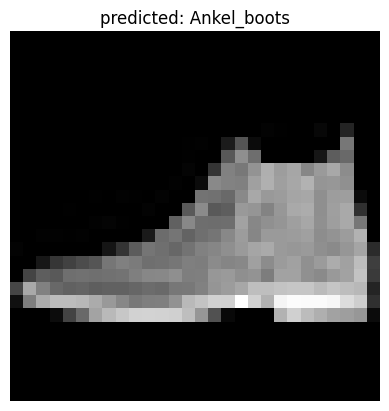

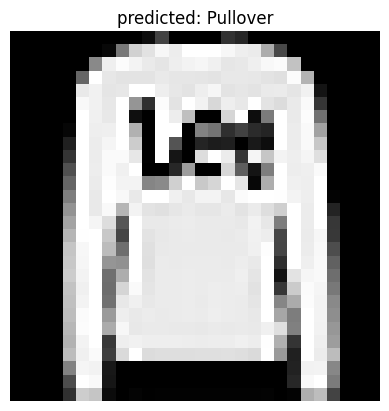

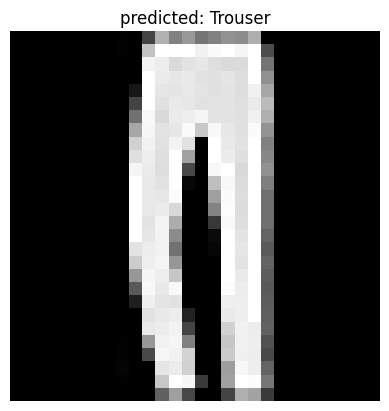

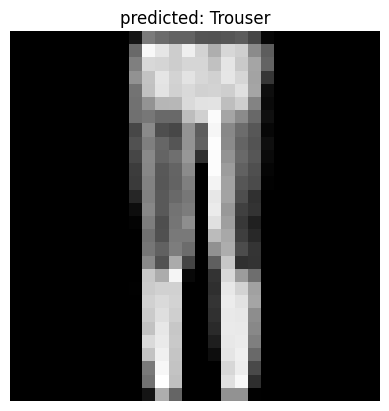

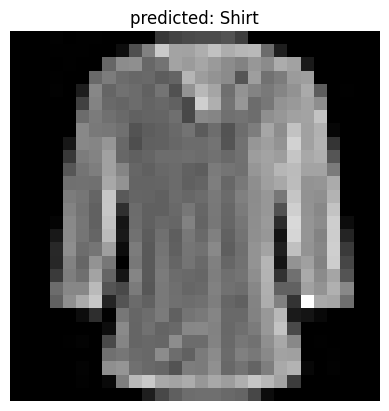

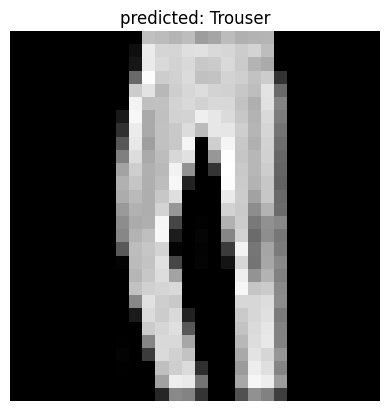

In [ ]:
for i in range(6):
  plt.imshow(test_img[i].reshape(28,28),cmap='grey')
  plt.title(f"predicted: {class_names[predicted_labels[i]]}")
  plt.axis('off')
  plt.show()